<a href="https://colab.research.google.com/github/Bendrox/Legal_API_LegiFrance/blob/main/Explore_L%C3%A9giFrance_API_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>







<div style="text-align: center;">
    <img src="https://piste.gouv.fr/images/logo-Piste-large.png" alt="Logo Piste" width="400" />
</div>









# I. Présentation de l'API LégiFrance :

Au total : ~70 requêtes API classées en 6 grandes familles.





### Familles de requêtes développées



#### 1. **Consult Controller**
- **Objectif** : Récupérer des informations spécifiques législatives ou réglementaires (textes, articles, etc.).
- **Fonctionnalités** :
  - Obtenir un article spécifique via son `id`.
  - Récupérer des détails sur une loi ou un texte réglementaire précis.



#### 2. **Chrono Controller**
- **Objectif** : Accéder à l'historique et à l'évolution chronologique des textes.
- **Fonctionnalité** :
  - Suivre les modifications ou révisions d’un texte au fil du temps.



#### 3. **List Controller**
- **Objectif** : Fournir des listes de documents basées sur des critères spécifiques.
- **Fonctionnalités** :
  - Lister tous les articles d'un code particulier.
  - Récupérer la liste des décrets associés à une loi.





### Familles de requêtes non développées



#### 4. **Suggest Controller**
- **Objectif** : Fournir des suggestions basées sur une recherche partielle.
- **Fonctionnalités** :
  - Rechercher un texte via des mots-clés ou des fragments.



#### 5. **Misc Controller**
- **Objectif** : Récupérer des métadonnées ou des informations auxiliaires.
- **Fonctionnalités** :
  - Obtenir des données complémentaires sur les textes ou documents.



#### 6. **Search Controller**
- **Objectif** : Effectuer des recherches globales sur les textes, articles, codes, etc., en fonction de mots-clés ou d'autres critères.
- **Fonctionnalités** :
  - Rechercher des textes ou articles pertinents par mots-clés.
  - Filtrer les résultats en fonction de critères spécifiques.


### Listes to do:

- dataframe (flatten)
- contenu article N vs N-1
- test sur cmf
- subdiviser balise html

Feedback:
- plus utiliser pandas,
- pas plus que deux boucles for
- des le dapart développer en fonction
- passer apres en .py


# II. Solution

# 1 - LégiFrance API connect

## 1.0 - Id's input

In [1]:
import getpass
client_id = getpass.getpass("Enter the client_id Key: ")

Enter the client_id Key: ··········


In [2]:
client_secret = getpass.getpass("Enter the client_secret Key: ")

Enter the client_secret Key: ··········


## 1.1 - API Get access token

In [4]:
import sys
print(sys.version)

3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]


In [5]:
pip install python-dotenv

In [6]:
import os
from dotenv import load_dotenv
import requests
from requests_oauthlib import OAuth2Session
import json

In [7]:
#option 2:
import requests


# URL pour obtenir le jeton
token_url = 'https://sandbox-oauth.piste.gouv.fr/api/oauth/token'

# inject cred for token request
token_data = {
    'grant_type': 'client_credentials',
    'client_id': client_id,
    'client_secret': client_secret,
    'scope': 'openid'
}

# run the request
response = requests.post(token_url, data=token_data)
response.raise_for_status()  # vérif  erreurs

# récup  jeton
token_info = response.json()
access_token = token_info['access_token']

## 1.2 - Ping/Pong request Test

In [36]:
import requests

def Ping_Pong_test():
    headers_1 = {'accept': 'text/plain', 'Authorization': 'Bearer ' + access_token}
    output = requests.get("https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/ping", headers=headers_1).text
    print(output)

Ping_Pong_test()


pong


# 2 - Requêtes - API calls



### 2.1.1 - Contenu Article - avec Eli (Fait)






Eli - Identifiant Européen de la Législation:

- Permet d'identifier de façon unique les documents législatifs et réglementaires au sein de la base de données de Légifrance.

- Déclinaison :

/eli : Préfixe indiquant qu'il s'agit d'un identifiant ELI.

/decret : Type de texte (ici un décret) peut aussi être un arrêté, une loi, ou d'autres types d'actes normatifs...

/2021/7/13 : Date de publication ou adoption (13 juillet 2021 dans cet exemple).

/PRMD2117108D : Numéro unique du décret

/jo : Indication que le document a été publié dans le Journal Officiel.

/article_1 : Référence à un article spécifique dans le document (ici l'article 1).


In [67]:
def get_article_byELI(idEliOrAlias):
  headers_2 = {"accept": "application/json","Content-Type": "application/json", 'Authorization': 'Bearer ' + access_token}
  data = {"idEliOrAlias": idEliOrAlias } # exemple: "/eli/decret/2021/7/13/PRMD2117108D/jo/article_1"
  url= "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleWithIdEliOrAlias"
  response = requests.post(url, headers=headers_2,json=data)
  response_json = response.json()
  return {
        "etat": response_json['article']['textTitles'][1]['etat'],
        "id": response_json['article']['id'],
        "titresTM": response_json['article']['context']['titresTM'],
        "titreLong": response_json['article']['textTitles'][1]["titreLong"],
        "texte": response_json['article']['texte']
    }


In [68]:
get_article_byELI("") # exemple: /eli/decret/2021/7/13/PRMD2117108D/jo/article_1

{'etat': 'VIGUEUR',
 'id': 'JORFARTI000043788371',
 'titresTM': [{'debut': '2999-01-01',
   'fin': '2999-01-01',
   'titre': 'Chapitre Ier : Attributions du secrétaire général de la défense et de la sécurité nationale en matière de lutte contre les ingérences numériques étrangères',
   'xPath': '/ARTICLE/CONTEXTE/TEXTE/TM/TITRE_TM',
   'cid': 'JORFSCTA000043788368',
   'id': 'JORFSCTA000043788368',
   'etat': ''}],
 'titreLong': "Décret n° 2021-922 du 13 juillet 2021 portant création, auprès du secrétaire général de la défense et de la sécurité nationale, d'un service à compétence nationale dénommé « service de vigilance et de protection contre les ingérences numériques étrangères »",
 'texte': "Le code de la défense est ainsi modifié : 1° L'article R.* 1132-3 est complété par un 9° ainsi rédigé : « 9° En liaison avec les départements ministériels concernés, il identifie les opérations impliquant, de manière directe ou indirecte, un Etat étranger ou une entité non étatique étrangère, e

### 2.1.2 - Contenu texte type CODE  /consult/code (Fait - pas utile)


Fonction : Permet d'obtenir le contenu complet d'un code juridique

Inputs :

- Inclure les articles abrogés Y/N: "abrogated": true

- L'identifiant unique du texte législatif: "textId": "LEGITEXT000006075116"

- Recherche par chaine de caractère: "searchedString": "constitution 1958"

-  Rechercher les textes dans leur version applicable à cette date précise:  "date": "2021-04-15"

-  Pour indiquer si la recherche a été initiée à partir d'une suggestion de recherche: "fromSuggest": true

- Identifiant unique d'une section ou subdivision spécifique dans un code ou texte juridique: "sctCid": "LEGISCTA000006112861"


In [ ]:
import requests


headers = {
    "Authorization": "Bearer " +access_token ,
    "Content-Type": "application/json",
}

BASE_URL = "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/code"


data = {
    "textId": "LEGITEXT000006073984",  # Code des assurances
    "sctCid": "LEGIARTI000048769089",  # ID article
    "abrogated": False,                # exclure les textes abrogés
    "date": "2024-11-15",              # Date de référence
    "fromSuggest": False               # Pas issue d'une suggestion
}



# Envoyer la requête POST
response = requests.post(BASE_URL, json=data, headers=headers)
response


<Response [200]>

In [ ]:
response_json = response.json()

In [ ]:
response_json.keys()

dict_keys(['executionTime', 'dereferenced', 'id', 'idConteneur', 'cid', 'title', 'nor', 'eli', 'alias', 'jorfText', 'jurisState', 'visa', 'modifDate', 'jurisDate', 'dateDebutVersion', 'dateFinVersion', 'signers', 'prepWork', 'dateParution', 'dateTexte', 'numParution', 'notice', 'nota', 'inap', 'textNumber', 'textAbroge', 'etat', 'dossiersLegislatifs', 'nature', 'resume', 'rectificatif', 'motsCles', 'appellations', 'liens', 'observations', 'sections', 'articles', 'pagePdf', 'fileName', 'fileSize', 'filePath'])

In [ ]:
response_json['title']

'Code des assurances'

In [ ]:
response_json['sections'][0]['title']


'Partie législative'

In [ ]:
response_json['sections'][0]['etat']


'VIGUEUR'

In [ ]:
response_json['sections'][0]['sections'][0]['title']


'Livre Ier : Le contrat'

In [ ]:
response_json['sections'][0]['sections'][0]['sections'][0]['title']

'Titre Ier : Règles communes aux assurances de dommages et aux assurances de personnes'

### 2.1.3 - Contenu des versions d'un article /consult/getArticleByCid (Fait)


Récupère la liste des articles par leur identifiant commun


Input: "cid": "LEGIARTI000006307920"



In [ ]:
import requests
import json

API_URL = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleByCid'


article_cid = 'LEGIARTI000028443554'
# OK Art cible, expl: LEGIARTI000028443554 - Article L421-4-2 + LEGIARTI000028443552

# KO Art modificateur (LEGIARTI000048769089, LEGIARTI000048769133, JORFTEXT000000507291)
# contiennent des instructions législatives et reg sur les modifications apportées à d'autres textes
# exemple: "supprimer", "ajouter", ou "modifier" un article d'un code...
# Getsectionbycid testé = KO

data = {
    'cid': article_cid,
}
# '1976-07-21' donne toutes les versions

headers = {
    'Authorization': 'Bearer ' + access_token,
    'Content-Type': 'application/json'
}

# Envoyer la requête POST
response = requests.post(API_URL, json=data, headers=headers)
response

<Response [200]>

In [ ]:
def getArticleByCid_basic(article_cid):
  API_URL = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleByCid'
  headers = {'Authorization': 'Bearer ' + access_token, 'Content-Type': 'application/json'}
  data = { 'cid': article_cid }
  response = requests.post(API_URL, json=data, headers=headers)
  response_json = response.json()
  return response.json()

In [ ]:
getArticleByCid_basic("LEGIARTI000048656149")

{'executionTime': 0, 'listArticle': []}

#### 2.1.3.1 - Get one version

In [ ]:
from datetime import datetime

def format_date(timestamp_ms):
    timestamp_s = timestamp_ms // 1000  # Convertir millisecondes en secondes
    return datetime.utcfromtimestamp(timestamp_s).strftime('%Y-%m-%d')

def getArticleByCid(article_cid):
  API_URL = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleByCid'
  headers = {'Authorization': 'Bearer ' + access_token, 'Content-Type': 'application/json'}
  data = { 'cid': article_cid }
  response = requests.post(API_URL, json=data, headers=headers)
  response_json = response.json()
  return {"Date Debut:" : format_date(response.json()['listArticle'][1]['dateDebut']),
          "Date Fin:": format_date(response.json()['listArticle'][1]['dateFin']),
          "Version:": response.json()['listArticle'][1]['versionArticle'],
          "Texte:": response.json()['listArticle'][1]['texte']
          }

In [ ]:
getArticleByCid("LEGIARTI000048252395")
# ok LEGIARTI000028443554

IndexError: list index out of range

#### 2.1.3.2 - Get all versions by Cid

In [ ]:
import requests

def get_articles_by_cid_all_versions(article_cid):
    API_URL = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleByCid'
    headers = {'Authorization': 'Bearer ' + access_token, 'Content-Type': 'application/json'}
    data = {'cid': article_cid}

    response = requests.post(API_URL, json=data, headers=headers)
    response_json = response.json()

    # Liste des articles récupérés
    articles = response_json.get('listArticle', [])

    # Résultats formatés
    formatted_articles = []
    for article in articles:
        formatted_articles.append({
            "Date Debut": format_date(article.get('dateDebut')),
            "Date Fin": format_date(article.get('dateFin')),
            "Version": article.get('versionArticle'),
            "Texte": article.get('texte')
        })

    return formatted_articles


In [ ]:
get_articles_by_cid_all_versions("LEGIARTI000028443554")

[{'Date Debut': '2023-12-31',
  'Date Fin': '2999-01-01',
  'Version': '4.0',
  'Texte': "Le taux des contributions mentionnées à l'article L. 421-4-1 est fixé par arrêté du ministre chargé des assurances dans les limites suivantes : 1° Pour la contribution des assurés, ce taux est compris entre 0 % et 2 % des primes mentionnées au 1° du même article ; 2° Pour la contribution des entreprises d'assurance, ce taux est compris entre 0 % et 1 % des primes ou cotisations mentionnées au 2° du même article L. 421-4-1 ; 3° (abrogé) ; 4° Pour la contribution des responsables d'accidents non assurés, ce taux est fixé à 10 % des indemnités restant à leur charge. Toutefois, ce taux peut être ramené à 5 % lorsque l'accident a été provoqué par un véhicule utilisé par l'Etat ou par un Etat étranger. Il est également ramené à 5 % des indemnités restant à leur propre charge pour les bénéficiaires d'une assurance avec franchise."},
 {'Date Debut': '2018-12-31',
  'Date Fin': '2023-12-31',
  'Version': '

#### 2.1.3.3 - Get article by cid + start_date

In [ ]:
import requests
from datetime import datetime

def get_article_text_by_cid_and_start_date(article_cid, start_date):
    API_URL = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleByCid'
    headers = {'Authorization': 'Bearer ' + access_token, 'Content-Type': 'application/json'}
    data = {'cid': article_cid}

    response = requests.post(API_URL, json=data, headers=headers)
    response_json = response.json()

    # Convertir la date en millisecondes depuis l'époque Unix
    start_date_timestamp = int(datetime.strptime(start_date, "%Y-%m-%d").timestamp() * 1000)

    # Parcourir les articles pour trouver une correspondance
    articles = response_json.get('listArticle', [])
    for article in articles:
        if article.get('dateDebut') == start_date_timestamp:
            return article.get('texte', "Texte non disponible")

    # Si aucun article ne correspond
    return "Aucun article trouvé pour la date de début donnée."


In [ ]:
get_article_text_by_cid_and_start_date("LEGIARTI000048252395",  "2023-10-25")
# Ok : "LEGIARTI000028443554",  "2018-07-01"
#

'Aucun article trouvé pour la date de début donnée.'

#### 2.1.3.3 - Get article by cid and date

In [ ]:
import requests
from datetime import datetime

def get_article_text_by_cid_and_end_date(article_cid, end_date):
    API_URL = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticleByCid'
    headers = {'Authorization': 'Bearer ' + access_token, 'Content-Type': 'application/json'}
    data = {'cid': article_cid}

    response = requests.post(API_URL, json=data, headers=headers)
    response_json = response.json()

    # Convertir la date en millisecondes depuis l'époque Unix
    end_date_timestamp = int(datetime.strptime(end_date, "%d-%m-%Y").timestamp() * 1000) #(ko: %Y-%m-%d ) (ko:"%d-%m-%Y" )

    # Parcourir les articles pour trouver une correspondance
    articles = response_json.get('listArticle', [])
    for article in articles:
        if article.get('dateFin') == end_date_timestamp:
            return article.get('texte', "Texte non disponible")

    # Si aucun article ne correspond
    return "Aucun article trouvé pour la date de début donnée."

In [ ]:
get_article_text_by_cid_and_end_date("LEGIARTI000048243369","25-10-2023") #KO :"LEGIARTI000046918899","2023-11-01"

'Aucun article trouvé pour la date de début donnée.'

### 2.1.4 - Contenu d'un dossier législatif JORF /consult/dossierLegislatif (Fait)



Récupère le contenu d'un dossier legislatif par son identifiant.

Input : Identifiant technique du dossier législatif "id": "JORFDOLE000038049286"



In [ ]:
import requests
import json

headers = {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
	}
url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/dossierLegislatif'

data = {"id":"JORFDOLE000038049286"}

reponse = requests.post(headers = headers , url= url, json= data)
reponse

<Response [200]>

In [ ]:
reponse.json()['dossierLegislatif']['titre']

"Ordonnance n° 2019-36 du 23 janvier 2019 portant diverses adaptations et dérogations temporaires nécessaires à la réalisation en urgence des travaux requis par le rétablissement des contrôles à la frontière avec le Royaume-Uni en raison du retrait de cet Etat de l'Union européenne"

In [ ]:
reponse.json()['dossierLegislatif'].keys()

dict_keys(['id', 'ancienId', 'origine', 'url', 'nature', 'titre', 'type', 'dateCreation', 'dateDerniereModification', 'legislature', 'echeancier', 'dateMajEcheancier', 'exposeMotif', 'arborescence', 'dossiers', 'refInjection', 'idTechInjection'])

In [ ]:
reponse.json()['dossierLegislatif']['dossiers']

[{'idTexte': 'JORFTEXT000038047573',
  'libelleTexte': "Ordonnance n° 2019-36 du 23 janvier 2019 portant diverses adaptations et dérogations temporaires nécessaires à la réalisation en urgence des travaux requis par le rétablissement des contrôles à la frontière avec le Royaume-Uni en raison du retrait de cet Etat de l'Union européenne",
  'contenuDossier': ''},
 {'idTexte': 'JORFTEXT000038047569',
  'libelleTexte': "Rapport au Président de la République relatif à l'ordonnance n° 2019-36 du 23 janvier 2019 portant diverses adaptations et dérogations temporaires nécessaires à la réalisation en urgence des travaux requis par le rétablissement des contrôles à la frontière avec le Royaume-Uni en raison du retrait de cet Etat de l'Union européenne",
  'contenuDossier': ''}]

### 2.1.5 - Contenu texte fonds LEGI /consult/legiPart ( Fait )


Récupère le contenu d'un texte / code du fonds LEGI à partir de son identifiant ("textId") et de sa date de vigueur:

In [ ]:
url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/legiPart'

headers = {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
  }

data = {
        #"searchedString":"constitution 1958",
        "date":"2021-04-15",
        "textId":"LEGITEXT000006075116"}

response = requests.post(url= url, headers =headers, json= data )
response

<Response [200]>

In [ ]:
response_json = response.json()

In [ ]:
response_json.keys()

dict_keys(['executionTime', 'dereferenced', 'id', 'idConteneur', 'cid', 'title', 'nor', 'eli', 'alias', 'jorfText', 'jurisState', 'visa', 'modifDate', 'jurisDate', 'dateDebutVersion', 'dateFinVersion', 'signers', 'prepWork', 'dateParution', 'dateTexte', 'numParution', 'notice', 'nota', 'inap', 'textNumber', 'textAbroge', 'etat', 'dossiersLegislatifs', 'nature', 'resume', 'rectificatif', 'motsCles', 'appellations', 'liens', 'observations', 'sections', 'articles', 'pagePdf', 'fileName', 'fileSize', 'filePath'])

### 2.1.7 - Contenu d'un article /consult/getArticle (Fait)


Récupère un article par son identifiant (id)

id : ID unique de la version de l'article pour accéder directement à une version particulière (historique ou active).



In [ ]:
headers= {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
	}

url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticle'


data = {"id":"LEGIARTI000006307920"}

response= requests.post(url=url,  headers=headers, json = data)
response

<Response [200]>

In [ ]:
response.json().keys()

dict_keys(['executionTime', 'dereferenced', 'article'])

In [ ]:
def getArticle(id : str):
  headers= {'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token}
  url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/consult/getArticle'
  data = {"id":id}
  response= requests.post(url=url,  headers=headers, json = data)
  return response.json()


In [ ]:
getArticle("LEGIARTI000048252395")

{'executionTime': 0,
 'dereferenced': False,
 'article': {'id': 'LEGIARTI000048252395',
  'idTexte': None,
  'type': 'AUTONOME',
  'texte': "I. – Le plan d'épargne retraite populaire est un contrat régi par l'article L. 141-1 dont l'exécution est liée à la cessation d'activité professionnelle et qui est souscrit par une association relevant de l'article L. 141-7 dénommée groupement d'épargne retraite populaire. Le contrat mentionné au premier alinéa a pour objet l'acquisition et la jouissance de droits viagers personnels payables à l'adhérent à compter au plus tôt de la date de liquidation de sa pension dans un régime obligatoire d'assurance vieillesse ou de l'âge fixé en application de l' article L. 351-1 du code de la sécurité sociale . Le contrat peut également prévoir le paiement d'un capital à cette même date, à condition que la valeur de rachat de cette garantie n'excède pas 20 % de la valeur de rachat du contrat. Le contrat peut prévoir des garanties complémentaires en cas de dé

## 2.2 - Chrono Controller




1 - Extrait d'une version d'un texte:
POST
/chrono/textCidAndElementCid - ok

2 - Vérifie si un texte possède des versions:
GET
/chrono/textCid/{textCid} - ok

3 - Version d'un texte:
POST
/chrono/textCid - ok

4 - Test controller:
GET
/chrono/ping

### 2.2.1  Extrait d'une version d'un texte  /chrono/textCidAndElementCid (Fait - pas utile)

Récupère un extrait (section ou article) d'une version spécifique d'un texte à partir des identifiants du texte (textCid) et de l'extrait section ou article: "elementCid"


In [ ]:
import requests

headers = {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token
	}

url = "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCidAndElementCid"

# elementCid id unique pour contenu juridique :
# exemple  article de loi,  section,  chapitre ou  autre subdivision juridique.

data = {
    "textCid": "LEGITEXT000006072050", # code du travail
    "elementCid": "LEGIARTI000006901817" # Article L2262-8
}
# Test 1: "textCid": "LEGITEXT000006070721" Code Civil, "elementCid": "LEGIARTI000038033084" -> NA
# Test 2: "textCid": "LEGITEXT000006070721" Code Civil , "elementCid": "LEGIARTI000006417324" -> NA
# Test 3 : "textCid": "LEGITEXT000006072050" Code du Travail + Article L1221-1 "elementCid": "LEGIARTI000006901817" -> ok
# https://www.legifrance.gouv.fr/codes/article_lc/LEGIARTI000006900839

In [ ]:
#  requête GET
response_2_6_1 = requests.post(url, headers=headers, json= data)

### 2.2.2  Version d'un texte /chrono/textCid - Binary output (Fait)



Input values for text_cid:

- LEGITEXT000006073984 # code des assurances

- LEGITEXT000006070721 # code civil

- LEGITEXT000005634379 # Code de commerce

- LEGITEXT000006070719 # code pénal  

- LEGITEXT000006072026 # cmf

In [ ]:
import requests


text_cid = "LEGITEXT000006073984" # input

# URL de l'API + inject textCid
url = f"https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCid/{text_cid}"


headers = {
    "accept": "application/json",
    "Authorization": "Bearer " + access_token
}

# Envoi  requête GET
response = requests.get(url, headers=headers)
data = response.json()
display(data)


In [ ]:
type(data)

In [ ]:
def version_exist(text_cid):
  url = f"https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCid/{text_cid}"
  headers = {
    "accept": "application/json",
        "Authorization": "Bearer " + access_token}
  response = requests.get(url, headers=headers)
  data = response.json()
  return display(data["chronolegiExists"])

In [ ]:
version_exist("LEGITEXT000006073984")
# LEGITEXT000006073984 # code des assurances : oui
# LEGITEXT000006070721 # code civil : oui
# LEGITEXT000005634379 # Code de commerce : oui
# LEGITEXT000006070719 # code pénal  oui
# LEGITEXT000006072026 # cmf

### 2.2.3 - Récupère une version (plage de dates) d'un texte (textCid) et version en vigueur (date) (Fait)




Exemple:

- Consulter le texte spécifié par textCid ("LEGITEXT000006070721").

- Voir les versions de ce texte entre 2015 et 2023


#### 2.2.3.1 - Requête

In [ ]:
import requests

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
    'Authorization': 'Bearer ' + access_token
}

# Données de la requête
data = {
  "endYear": 2023,
  #"dateConsult": "2021-04-15", # consulter la version du texte qui était en vigueur le 15 avril 2021
  "startYear": 2020,
  "textCid": "LEGITEXT000006073984" # code des assurances
}

url = 'https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/chrono/textCid'

# Envoi de la requête POST
response = requests.post(url, headers=headers, json=data)
display(response)

<Response [200]>

In [ ]:
data_json_2_2_3 = response.json()
data_json_2_2_3.keys()

dict_keys(['executionTime', 'regroupements', 'datePublication'])

#### 2.2.3.5 Data pipeline 1: Data Print

In [ ]:
from datetime import datetime as dt
# Data cleaning
annee_recherchee = "2023"
resultat = ""

# Vérifier la présence du champ 'regroupements' et l’analyser
for group_1 in data_json_2_2_3['regroupements']:  # Parcours regroupement d'années : list de dictionnaires
    if group_1['title'] == annee_recherchee:  # Filtre pour l'année recherchée
        print(f"Année : {group_1['title']}")
        #resultat = resultat+ group_1['title'] + "n"

        # Parcours de chaque version de texte pour l'année courante
        for version_date, version_data in group_1['versions'].items():
            # Convertir le timestamp en une date lisible
            date_debut = dt.fromtimestamp(version_data['dateDebut'] / 1000).strftime('%Y-%m-%d')

            print(f"  Version du {version_date}:")
            print(f"    Date de début cible entrée en vigueur: {date_debut}")
            print(f"    Est la dernière version : {'Oui' if version_data['isEndVersion'] else 'Non'}")

            # Affichage des articles modificateurs
            print("    Articles modificateurs :")
            for article_id, article_data in version_data['articlesModificateurs'].items():
                print(f"      - ID : {article_id}")
                print(f"        Titre : {article_data['title']}")
                print(f"        Nature : {article_data['nature']}")
                date_debut_cible = dt.fromtimestamp(article_data['dateDebutCible'] / 1000).strftime('%Y-%m-%d')
                print(f"        Date de début cible : {date_debut_cible}")

                # Affichage des actions et des parents si disponibles
                if 'actions' in article_data:
                    for action_type, action_details in article_data['actions'].items():
                        print(f"        Action : {action_type}")

                        if 'parents' in action_details:
                            print("        Parents :")
                            for parent_id, parent_data in action_details['parents'].items():
                                print(f"          - ID parent  : {parent_id}")
                                print(f"            Nom parent : {parent_data['name']}")
                                print(f"            CID parent : {parent_data['cid']}")
                                if 'articlesCibles' in parent_data:
                                    print("            Articles cibles :")
                                    for cible_id, cible_data in parent_data['articlesCibles'].items():
                                        print(f"              - ID :{cible_id} - Article N° {cible_data['name']}")
                                        print(f"                    Date de début : {dt.fromtimestamp(cible_data['dateDebut'] / 1000).strftime('%Y-%m-%d')}")
                                        print(f"                    Date de fin : {dt.fromtimestamp(cible_data['dateFin'] / 1000).strftime('%Y-%m-%d')}")



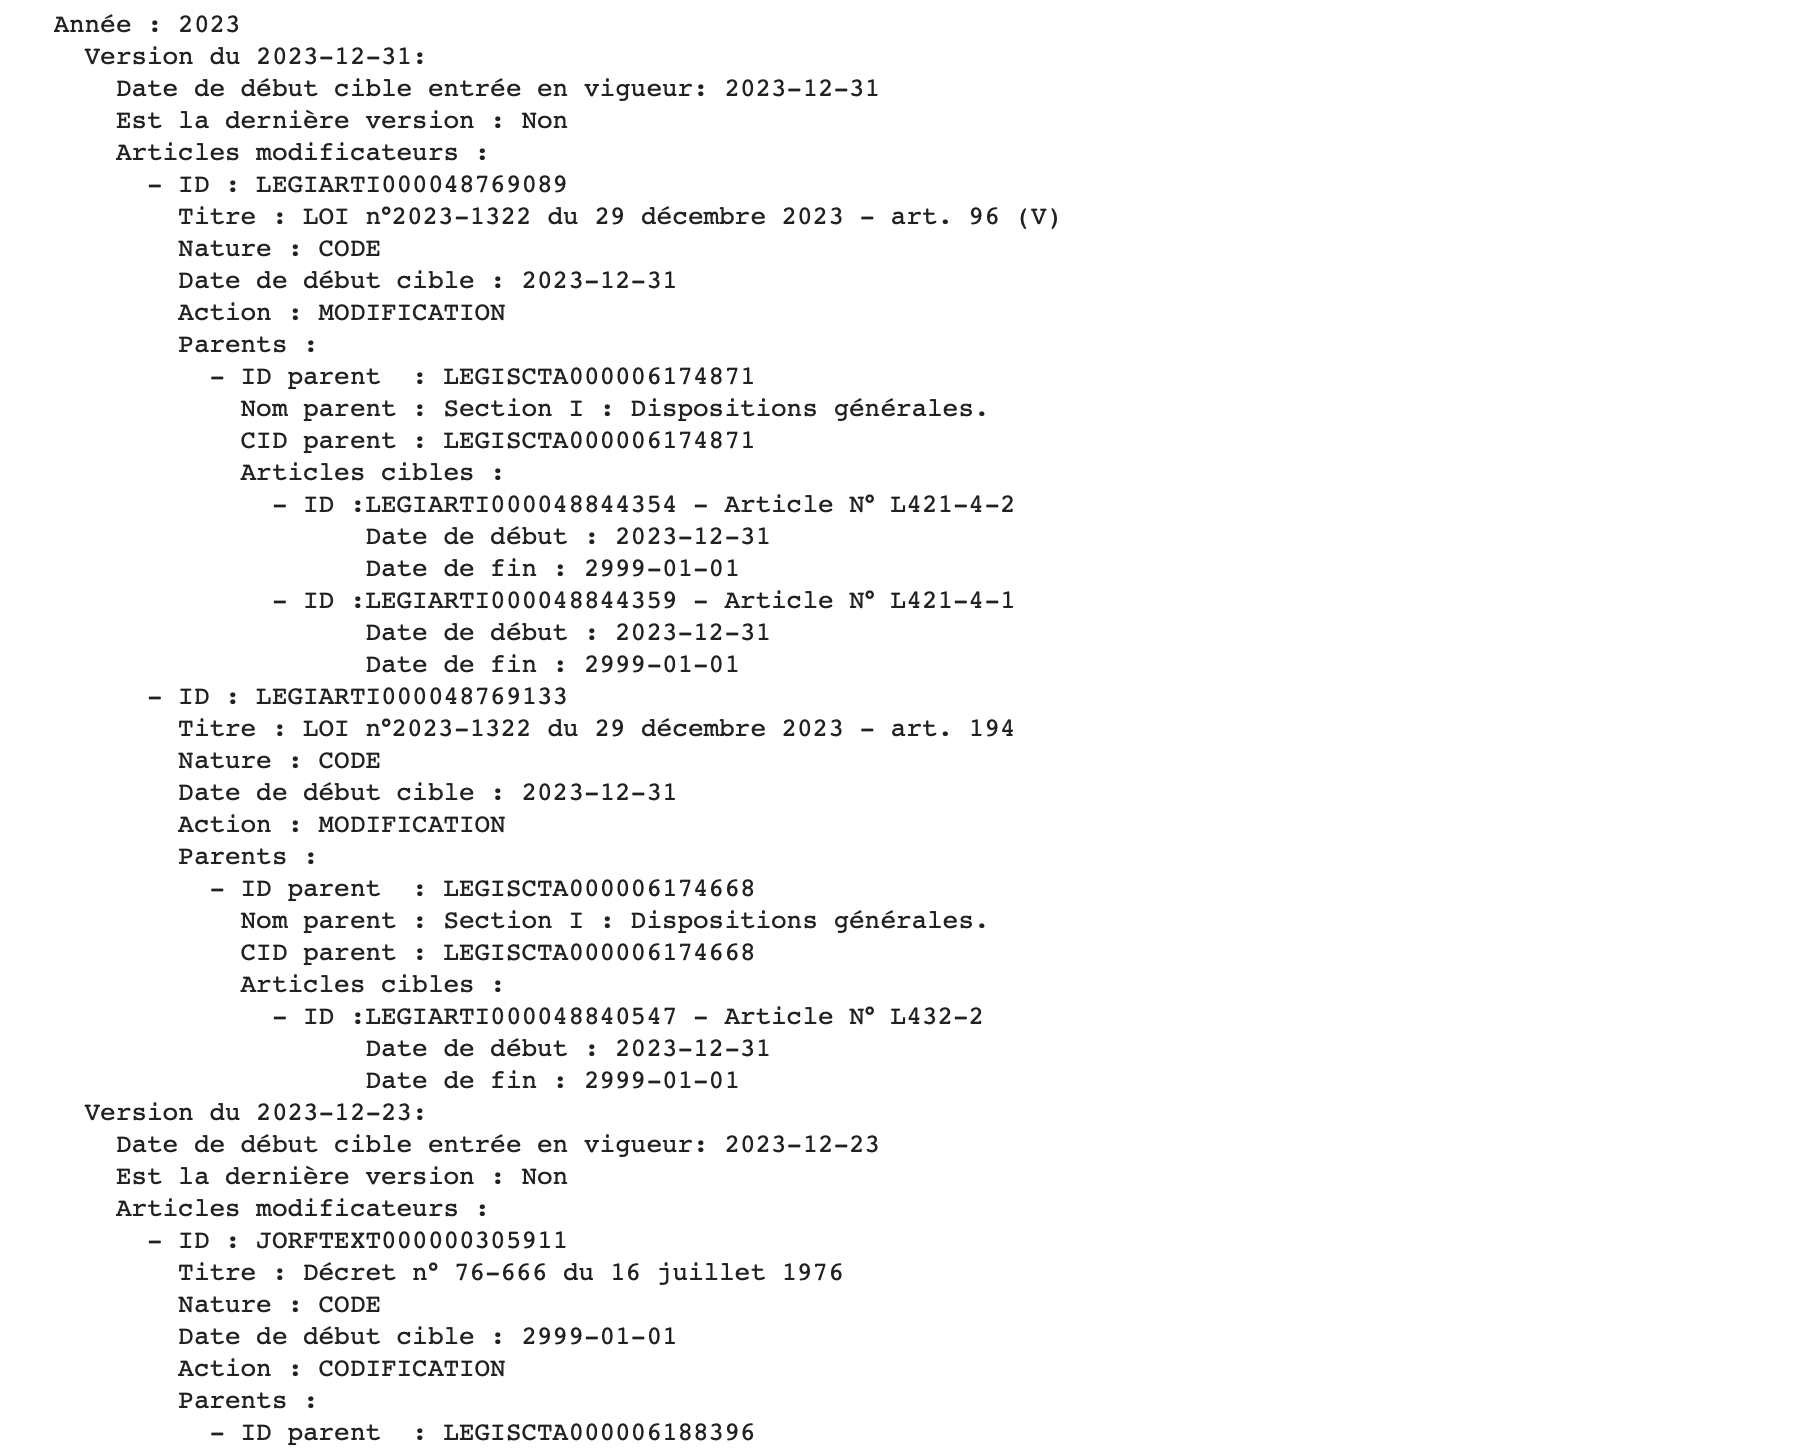

#### 2.2.3.5 Data pipeline 2: To pd.DataFrame

In [ ]:
from datetime import datetime

def convert_timestamp(timestamp):
    """
    Convertit un timestamp en millisecondes en une date lisible (YYYY-MM-DD).
    """
    if timestamp is None:
        return None
    return datetime.utcfromtimestamp(timestamp / 1000).strftime('%Y-%m-%d')


In [ ]:
import pandas as pd

In [ ]:
def transform_json_to_dataframe(data):
    """
    Transforme le JSON en DataFrame structuré avec les colonnes demandées.
    """
    rows = []

    for regroupement in data["regroupements"]:
        year = regroupement["title"]
        for version, version_data in regroupement["versions"].items():
            date_debut_version = convert_timestamp(version_data.get("dateDebut"))
            is_last_version = version_data.get("isEndVersion", False)
            articles_modificateurs = version_data.get("articlesModificateurs", {})

            for article_id, article_data in articles_modificateurs.items():
                title_article = article_data.get("title")
                nature_article = article_data.get("nature")
                date_debut_cible_article = convert_timestamp(article_data.get("dateDebutCible"))
                actions = article_data.get("actions", {})

                for action_type, action_data in actions.items():
                    parents = action_data.get("parents", {})
                    for parent_id, parent_data in parents.items():
                        parent_name = parent_data.get("name")
                        parent_cid = parent_data.get("cid")
                        articles_cibles = parent_data.get("articlesCibles", {})

                        for article_cible_id, article_cible_data in articles_cibles.items():
                            article_cible_name = article_cible_data.get("name")
                            article_cible_date_debut = convert_timestamp(article_cible_data.get("dateDebut"))
                            article_cible_date_fin = convert_timestamp(article_cible_data.get("dateFin"))

                            # Ajouter une ligne au tableau
                            rows.append({
                                "Année": year,
                                "Version du": version,
                                "Date de début cible d'entrée en vigueur": date_debut_version,
                                "Est la dernière version": is_last_version,
                                "ID Article Modificateur": article_id,
                                "Titre Article Modificateur": title_article,
                                "Nature Article Modificateur": nature_article,
                                "Date de début cible Article Modificateur": date_debut_cible_article,
                                "Action Article Modificateur": action_type,
                                "ID Parent": parent_id,
                                "Nom Parent": parent_name,
                                "CID Parent": parent_cid,
                                "ID Article Cible": article_cible_id,
                                "Titre Article Cible": article_cible_name,
                                "Date de début (Article Cible)": article_cible_date_debut,
                                "Date de fin (Article Cible)": article_cible_date_fin
                            })

    return pd.DataFrame(rows)


In [ ]:
df_2_2_3 = transform_json_to_dataframe(data_json_2_2_3)

In [ ]:
from google.colab import files
df_2_2_3.to_excel('output.xlsx')
files.download("output.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### 2.2.3.6 Data pipeline 3: Flatten Multi index pd.DataFrame



In [ ]:
import pandas as pd
from pandas import json_normalize

def convert_timestamps(df):
    for col in df.columns:
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], unit="ms", errors="coerce")
    return df

def flatten_json_to_dataframe_multindex(data):
    flat_data = []

    for regroupement in data["regroupements"]:
        regroupement_title = regroupement["title"]

        for version, version_data in regroupement["versions"].items():
            date_debut = version_data["dateDebut"]
            is_end_version = version_data["isEndVersion"]
            articles_modificateurs = version_data.get("articlesModificateurs", {})

            for article_id, article_data in articles_modificateurs.items():
                actions = article_data.get("actions", {})

                for action_type, action_data in actions.items():
                    parents = action_data.get("parents", {})

                    for parent_id, parent_data in parents.items():
                        articles_cibles = parent_data.get("articlesCibles", {})

                        for cible_id, cible_data in articles_cibles.items():
                            flat_data.append({
                                "Année": regroupement_title,
                                "Version du": version,
                                "Date de début cible d'entrée en vigueur": date_debut,
                                "Est la dernière version": is_end_version,
                                "ID Article Modificateur": article_id,
                                "Titre Article Modificateur": article_data.get("title"),
                                "Nature Article Modificateur": article_data.get("nature"),
                                "Date de début cible Article Modificateur": article_data.get("dateDebutCible"),
                                "Action Article Modificateur": action_type,
                                "ID Parent": parent_id,
                                "Nom Parent": parent_data.get("name"),
                                "CID Parent": parent_data.get("cid"),
                                "ID Article Cible": cible_id,
                                "Titre Article Cible": cible_data.get("name"),
                                "Date de début (Article Cible)": cible_data.get("dateDebut"),
                                "Date de fin (Article Cible)": cible_data.get("dateFin"),
                            })

    df = pd.DataFrame(flat_data)
    df = convert_timestamps(df)  # Convertir les timestamps en dates lisibles
    return df.set_index(["Année", "Version du", "ID Article Modificateur", "ID Parent", "ID Article Cible"])


In [ ]:
from google.colab import files

data_2_6_3_multi_index = flatten_json_to_dataframe_multindex(data_json_2_2_3)
data_2_6_3_multi_index.to_excel('output_multi_index.xlsx')
files.download("output_multi_index.xlsx")

#### 2.2.3.7 - Data pipeline 4: Json_normalizer (To do)

In [ ]:
# Étape 1 : Normaliser les articles modificateurs
# df_modificateurs = pd.json_normalize(
# df_2_6_3["versions"],
# record_path=["articlesModificateurs", "MODIFICATION", "parents", "articlesCibles"],
# meta=[["articlesModificateurs", "id"],
# ["articlesModificateurs", "title"],
# ["articlesModificateurs", "nature"]],
# meta_prefix="mod_",
# eecord_prefix="cible_")

# Étape 2 : Affichage du DataFrame
# print(df_2_6_3)

## 2.3 - List controleur - Liste paginée des codes /list/code (Fait)

Récupère les cid des codes recherche mot clé et autres données



In [ ]:
url =  "https://sandbox-api.piste.gouv.fr/dila/legifrance/lf-engine-app/list/code"
headers= {
		'accept': 'application/json',
		'Content-Type': 'application/json',
		'Authorization': 'Bearer ' + access_token}

data=  {
        "sort":"TITLE_ASC",
        "pageSize":10,
        "states":["VIGUEUR"], # autres valo : ,"ABROGE","VIGUEUR_DIFF"
        "pageNumber":1,"codeName":"Code assurance"
        }

response = requests.post(url,
                         headers=headers,
                         json=data)

In [ ]:
response.json()

{'executionTime': 46,
 'results': [{'id': 'LEGITEXT000006073984',
   'cid': 'LEGITEXT000006073984',
   'etat': 'VIGUEUR',
   'titre': 'Code des assurances',
   'dateDebut': '1976-07-11T00:00:00.000+0000',
   'dateFin': '2999-01-01T00:00:00.000+0000',
   'lastUpdate': '2024-11-02T00:00:00.000+0000',
   'pdfFileName': 'LEGITEXT000006073984.pdf',
   'pdfFileSize': '2,2 Mo',
   'pdfFilePath': '/LEGI/TEXT/00/00/06/07/39/84/LEGITEXT000006073984/LEGITEXT000006073984.pdf'}],
 'states': {'facetElem': None,
  'field': 'etat',
  'values': {'VIGUEUR': 1},
  'childs': {},
  'totalElement': 0},
 'codeNames': {'facetElem': None,
  'field': 'titreLong',
  'values': {'Code des assurances': 1},
  'childs': {},
  'totalElement': 0},
 'totalResultNumber': 1}

# 3 - Output dataframe Wrap-up

In [ ]:
df_2_2_3.columns

Index(['Année', 'Version du', 'Date de début cible d'entrée en vigueur',
       'Est la dernière version', 'ID Article Modificateur',
       'Titre Article Modificateur', 'Nature Article Modificateur',
       'Date de début cible Article Modificateur',
       'Action Article Modificateur', 'ID Parent', 'Nom Parent', 'CID Parent',
       'ID Article Cible', 'Titre Article Cible',
       'Date de début (Article Cible)', 'Date de fin (Article Cible)'],
      dtype='object')

In [ ]:
df_2_2_3.dtypes

,0
Année,object
Version du,object
Date de début cible d'entrée en vigueur,object
Est la dernière version,bool
ID Article Modificateur,object
Titre Article Modificateur,object
Nature Article Modificateur,object
Date de début cible Article Modificateur,object
Action Article Modificateur,object
ID Parent,object


In [ ]:
df_2_2_3['Date de début (Article Cible)'] = df_2_2_3['Date de début (Article Cible)'].astype('str')

In [ ]:
df_2_2_3['ID Article Cible'] = df_2_2_3['ID Article Cible'].astype('str')

In [ ]:
df_2_2_3['contenu_Article_vAnc'] = df_2_2_3.apply(
    lambda x: get_article_text_by_cid_and_start_date(x['ID Article Cible'], x['Date de début (Article Cible)']), axis=1)

In [ ]:
from google.colab import files
df_2_2_3.to_excel("contenu_article2.xlsx")
files.download("contenu_article2.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>